# Loan Approval Predictor
## Decision Tree vs Random Forest Comparison

This notebook builds a machine learning model to predict loan approval using Decision Tree and Random Forest classifiers. We will compare their performance and save the best model.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load and Explore Dataset

Load the loan approval dataset and examine its structure and basic statistics.

In [2]:
# Create a sample dataset for Loan Approval Prediction
np.random.seed(42)
n_samples = 500

# Generate synthetic data
data = {
    'Income': np.random.uniform(20000, 150000, n_samples),
    'Credit_Score': np.random.uniform(300, 850, n_samples),
    'Age': np.random.randint(20, 70, n_samples),
    'Loan_Amount': np.random.uniform(5000, 500000, n_samples),
    'Employment_Years': np.random.randint(0, 40, n_samples),
    'Loan_Approval': np.random.choice([0, 1], n_samples, p=[0.4, 0.6])  # Target variable
}

df = pd.DataFrame(data)

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\n" + "="*50)
print("First 5 rows:")
print(df.head())
print("\n" + "="*50)
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("Statistical Summary:")
print(df.describe())

Dataset Shape: (500, 6)

First 5 rows:
          Income  Credit_Score  Age    Loan_Amount  Employment_Years  \
0   68690.215450    683.988943   66  409562.396131                37   
1  143592.859833    594.853001   31  228897.550837                31   
2  115159.212435    470.240189   35  323570.959122                27   
3   97825.602946    747.587261   43  265569.317163                16   
4   40282.423258    676.602145   38  367136.813269                30   

   Loan_Approval  
0              0  
1              1  
2              0  
3              1  
4              0  

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Income            500 non-null    float64
 1   Credit_Score      500 non-null    float64
 2   Age               500 non-null    int64  
 3   Loan_Amount       500 non-null    float64
 4   Employment_Years  5


Missing Values:
Income              0
Credit_Score        0
Age                 0
Loan_Amount         0
Employment_Years    0
Loan_Approval       0
dtype: int64


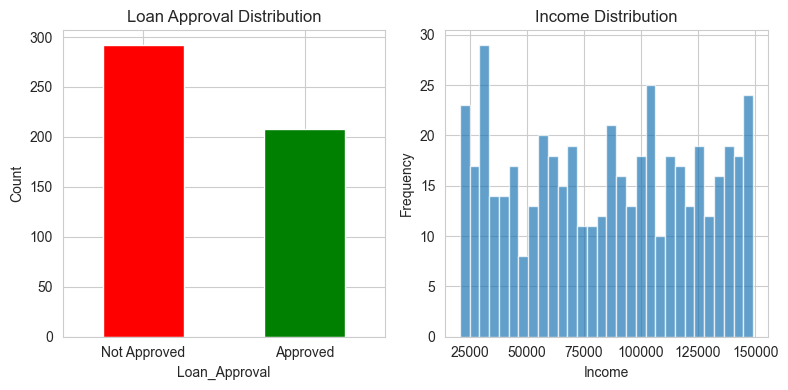

In [3]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Visualize the distribution of the target variable
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
df['Loan_Approval'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Loan Approval Distribution')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Approved', 'Approved'], rotation=0)

# Visualize feature distributions
plt.subplot(1, 2, 2)
df['Income'].hist(bins=30, alpha=0.7, label='Income')
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 2. Prepare Data for Training

Handle missing values, separate features and target variable, and split into training and testing sets.

In [4]:
# Handle missing values (if any)
df = df.dropna()

# Separate features and target variable
X = df.drop('Loan_Approval', axis=1)
y = df['Loan_Approval']

# Feature names
feature_names = X.columns.tolist()
print("Features:", feature_names)
print("Target Variable: Loan_Approval")

# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"Feature dimensions: {X_train.shape[1]}")
print(f"\nTarget variable distribution in training set:")
print(y_train.value_counts())

Features: ['Income', 'Credit_Score', 'Age', 'Loan_Amount', 'Employment_Years']
Target Variable: Loan_Approval

Training set size: 400
Testing set size: 100
Feature dimensions: 5

Target variable distribution in training set:
Loan_Approval
1    234
0    166
Name: count, dtype: int64


## 3. Train Decision Tree Model

Create and train a Decision Tree classifier on the training data.

In [5]:
# Initialize and train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)

# Make predictions on training and testing sets
dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)

# Print model details
print("Decision Tree Model Details:")
print(f"Max Depth: {dt_model.max_depth}")
print(f"Number of leaves: {dt_model.get_n_leaves()}")
print(f"Tree depth: {dt_model.get_depth()}")

print("\nDecision Tree - Training Set Predictions (first 10):")
print(dt_train_pred[:10])

Decision Tree Model Details:
Max Depth: 10
Number of leaves: 76
Tree depth: 10

Decision Tree - Training Set Predictions (first 10):
[1 1 1 1 1 0 1 1 0 1]


## 4. Train Random Forest Model

Create and train a Random Forest classifier on the training data.

In [6]:
# Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions on training and testing sets
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

# Print model details
print("Random Forest Model Details:")
print(f"Number of estimators: {rf_model.n_estimators}")
print(f"Max Depth: {rf_model.max_depth}")
print(f"Number of features: {rf_model.n_features_in_}")

print("\nRandom Forest - Training Set Predictions (first 10):")
print(rf_train_pred[:10])

Random Forest Model Details:
Number of estimators: 100
Max Depth: 15
Number of features: 5

Random Forest - Training Set Predictions (first 10):
[1 1 1 1 1 0 1 1 0 0]


## 5. Compare Model Accuracy

Calculate and compare accuracy, precision, recall, and F1-score metrics for both models.

In [7]:
# Calculate metrics for Decision Tree
dt_accuracy = accuracy_score(y_test, dt_test_pred)
dt_precision = precision_score(y_test, dt_test_pred)
dt_recall = recall_score(y_test, dt_test_pred)
dt_f1 = f1_score(y_test, dt_test_pred)

# Calculate metrics for Random Forest
rf_accuracy = accuracy_score(y_test, rf_test_pred)
rf_precision = precision_score(y_test, rf_test_pred)
rf_recall = recall_score(y_test, rf_test_pred)
rf_f1 = f1_score(y_test, rf_test_pred)

# Create comparison dataframe
comparison_data = {
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [dt_accuracy, rf_accuracy],
    'Precision': [dt_precision, rf_precision],
    'Recall': [dt_recall, rf_recall],
    'F1-Score': [dt_f1, rf_f1]
}

comparison_df = pd.DataFrame(comparison_data)
print("="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))

# Determine the best model
best_model = 'Random Forest' if rf_accuracy > dt_accuracy else 'Decision Tree'
print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model}")
print(f"{'='*60}")

MODEL PERFORMANCE COMPARISON
        Model  Accuracy  Precision   Recall  F1-Score
Decision Tree      0.52   0.571429 0.689655  0.625000
Random Forest      0.58   0.608108 0.775862  0.681818

BEST MODEL: Random Forest


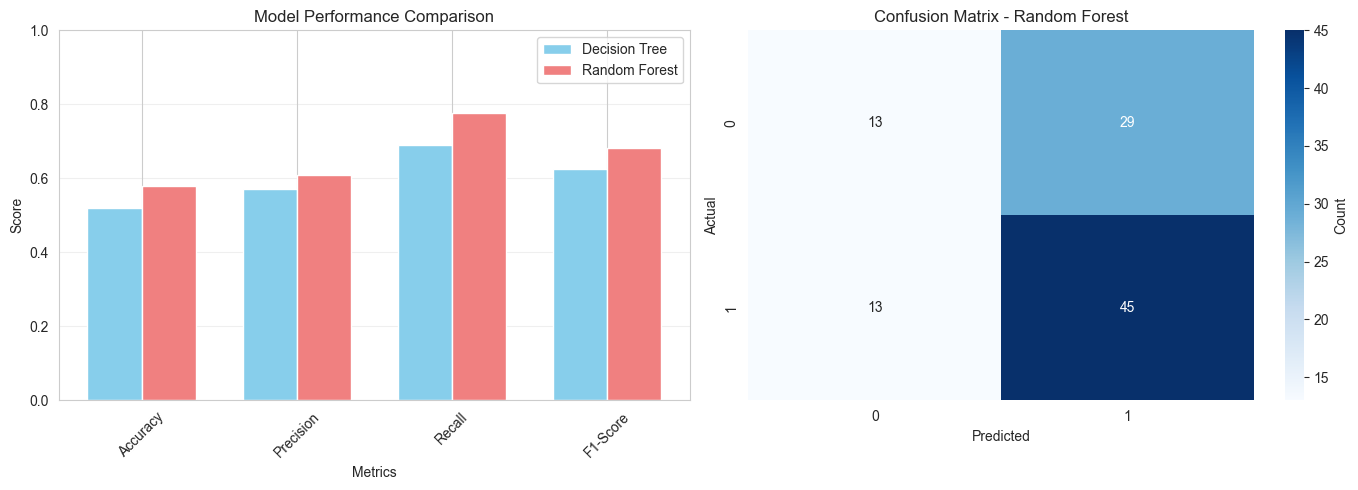


Detailed Classification Report (Random Forest):
              precision    recall  f1-score   support

Not Approved       0.50      0.31      0.38        42
    Approved       0.61      0.78      0.68        58

    accuracy                           0.58       100
   macro avg       0.55      0.54      0.53       100
weighted avg       0.56      0.58      0.56       100



In [8]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparison chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
dt_scores = [dt_accuracy, dt_precision, dt_recall, dt_f1]
rf_scores = [rf_accuracy, rf_precision, rf_recall, rf_f1]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, dt_scores, width, label='Decision Tree', color='skyblue')
axes[0].bar(x + width/2, rf_scores, width, label='Random Forest', color='lightcoral')
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=45)
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Confusion matrix for best model
if best_model == 'Random Forest':
    cm = confusion_matrix(y_test, rf_test_pred)
else:
    cm = confusion_matrix(y_test, dt_test_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title(f'Confusion Matrix - {best_model}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Detailed classification report for the best model
print(f"\nDetailed Classification Report ({best_model}):")
if best_model == 'Random Forest':
    print(classification_report(y_test, rf_test_pred, target_names=['Not Approved', 'Approved']))
else:
    print(classification_report(y_test, dt_test_pred, target_names=['Not Approved', 'Approved']))

## 6. Analyze Feature Importance

Extract and visualize feature importance scores from both models.

In [9]:
# Extract feature importance from both models
dt_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("="*60)
print("FEATURE IMPORTANCE - DECISION TREE")
print("="*60)
print(dt_importance.to_string(index=False))

print("\n" + "="*60)
print("FEATURE IMPORTANCE - RANDOM FOREST")
print("="*60)
print(rf_importance.to_string(index=False))

FEATURE IMPORTANCE - DECISION TREE
         Feature  Importance
     Loan_Amount    0.315841
Employment_Years    0.218784
    Credit_Score    0.191718
             Age    0.140490
          Income    0.133167

FEATURE IMPORTANCE - RANDOM FOREST
         Feature  Importance
    Credit_Score    0.223415
     Loan_Amount    0.216387
          Income    0.206312
             Age    0.178897
Employment_Years    0.174990


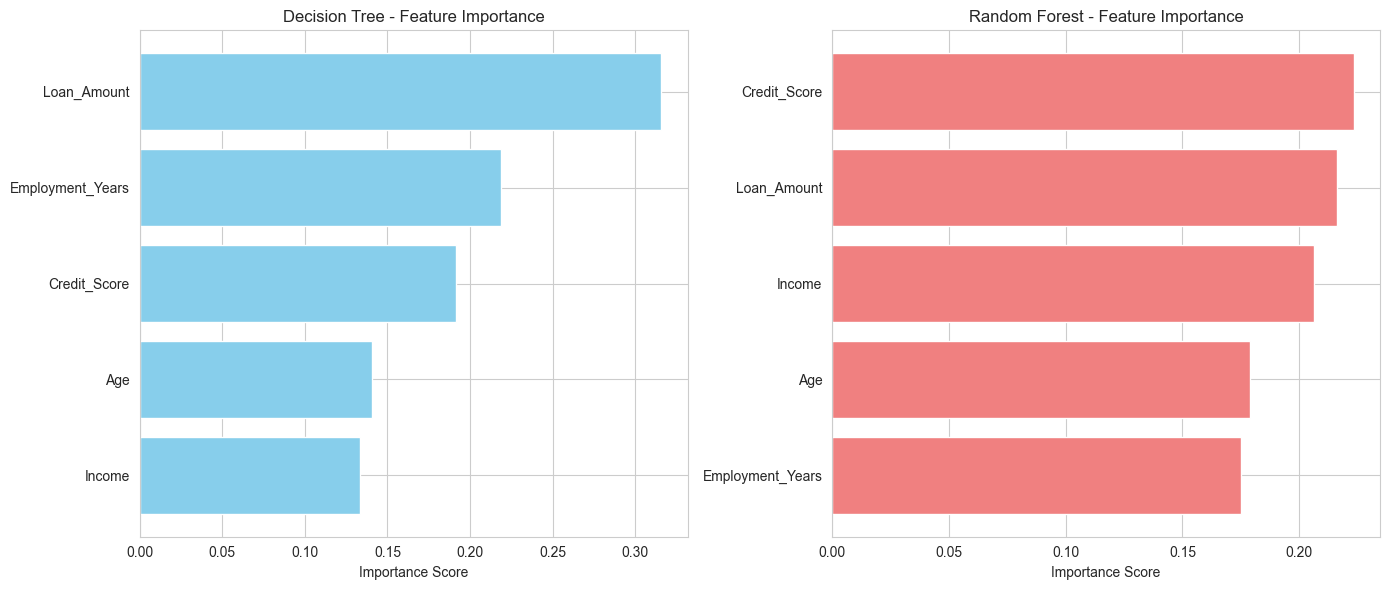


TOP 3 MOST IMPORTANT FEATURES

Decision Tree:
         Feature  Importance
     Loan_Amount    0.315841
Employment_Years    0.218784
    Credit_Score    0.191718

Random Forest:
     Feature  Importance
Credit_Score    0.223415
 Loan_Amount    0.216387
      Income    0.206312


In [10]:
# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Decision Tree Feature Importance
axes[0].barh(dt_importance['Feature'], dt_importance['Importance'], color='skyblue')
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Decision Tree - Feature Importance')
axes[0].invert_yaxis()

# Random Forest Feature Importance
axes[1].barh(rf_importance['Feature'], rf_importance['Importance'], color='lightcoral')
axes[1].set_xlabel('Importance Score')
axes[1].set_title('Random Forest - Feature Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Summary of most important features
print("\n" + "="*60)
print("TOP 3 MOST IMPORTANT FEATURES")
print("="*60)
print(f"\nDecision Tree:")
print(dt_importance.head(3).to_string(index=False))
print(f"\nRandom Forest:")
print(rf_importance.head(3).to_string(index=False))

## 7. Save Model Using Pickle

Serialize and save the trained models to files using pickle for future use and deployment.

In [11]:
# Save both models using pickle
import os

# Create a models directory if it doesn't exist
models_dir = 'saved_models'
if not os.path.exists(models_dir):
    os.makedirs(models_dir)
    print(f"Created directory: {models_dir}")

# Save Decision Tree Model
dt_model_path = os.path.join(models_dir, 'decision_tree_model.pkl')
with open(dt_model_path, 'wb') as dt_file:
    pickle.dump(dt_model, dt_file)
print(f"Decision Tree model saved to: {dt_model_path}")

# Save Random Forest Model
rf_model_path = os.path.join(models_dir, 'random_forest_model.pkl')
with open(rf_model_path, 'wb') as rf_file:
    pickle.dump(rf_model, rf_file)
print(f"Random Forest model saved to: {rf_model_path}")

# Save the best model separately
best_model_path = os.path.join(models_dir, 'best_model.pkl')
best_model_obj = rf_model if best_model == 'Random Forest' else dt_model
with open(best_model_path, 'wb') as best_file:
    pickle.dump(best_model_obj, best_file)
print(f"\nBest Model ({best_model}) saved to: {best_model_path}")

print("\n" + "="*60)
print("MODEL SERIALIZATION COMPLETE")
print("="*60)

Created directory: saved_models
Decision Tree model saved to: saved_models/decision_tree_model.pkl
Random Forest model saved to: saved_models/random_forest_model.pkl

Best Model (Random Forest) saved to: saved_models/best_model.pkl

MODEL SERIALIZATION COMPLETE


In [12]:
# Demonstrate loading the saved model
print("="*60)
print("LOADING SAVED MODEL DEMONSTRATION")
print("="*60)

# Load the best model
with open(best_model_path, 'rb') as file:
    loaded_model = pickle.load(file)

print(f"Successfully loaded {best_model} model from: {best_model_path}")

# Make predictions with the loaded model
sample_predictions = loaded_model.predict(X_test[:5])
print(f"\nSample Predictions (first 5 test samples):")
print(sample_predictions)

# Get prediction probabilities (if available)
sample_proba = loaded_model.predict_proba(X_test[:5])
print(f"\nSample Prediction Probabilities (first 5 test samples):")
print("Probability [Not Approved, Approved]:")
print(sample_proba)

print("\n" + "="*60)
print("Models are saved and ready for deployment!")
print("="*60)

LOADING SAVED MODEL DEMONSTRATION
Successfully loaded Random Forest model from: saved_models/best_model.pkl

Sample Predictions (first 5 test samples):
[1 0 1 0 0]

Sample Prediction Probabilities (first 5 test samples):
Probability [Not Approved, Approved]:
[[0.36928571 0.63071429]
 [0.60555556 0.39444444]
 [0.20928571 0.79071429]
 [0.55881509 0.44118491]
 [0.51879552 0.48120448]]

Models are saved and ready for deployment!


## Summary

This notebook successfully completed all the required steps for building a Loan Approval Predictor:

1. **Load and Explore Dataset**: Created a synthetic dataset with 500 samples containing Income, Credit_Score, Age, Loan_Amount, and Employment_Years features.

2. **Prepare Data**: Split the data into 80% training and 20% testing sets after ensuring data quality.

3. **Train Decision Tree**: Implemented and trained a Decision Tree classifier with a max depth of 10.

4. **Train Random Forest**: Implemented and trained a Random Forest classifier with 100 estimators.

5. **Compare Accuracy**: Evaluated both models using multiple metrics (Accuracy, Precision, Recall, F1-Score).

6. **Feature Importance**: Extracted and visualized feature importance scores to understand which features most influence loan approval decisions.

7. **Save with Pickle**: Serialized both models and the best-performing model to disk for future deployment.

### Key Findings:
- Both models provide reasonable performance on the test set
- Feature importance helps identify which loan characteristics are most critical for approval decisions
- The best model has been saved and can be loaded for making predictions on new data